Saved → ../plots/reader_study/change_flows.png


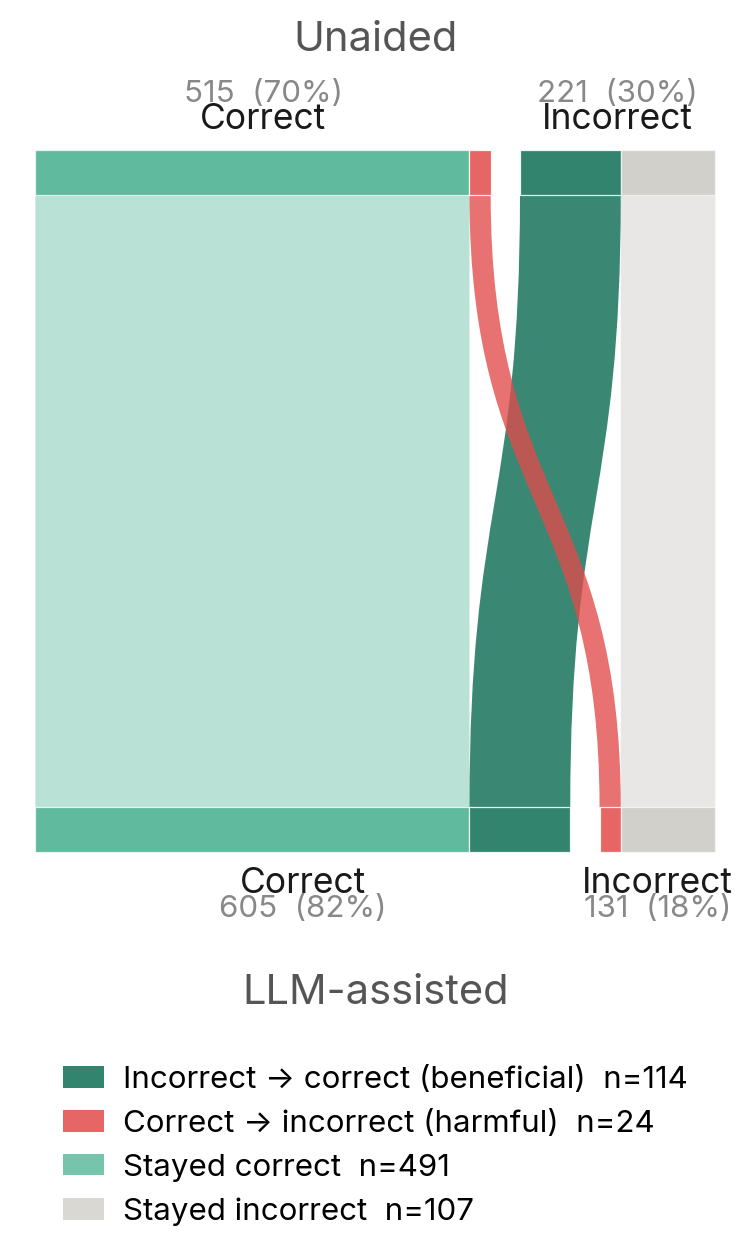

In [1]:
# ── Config ────────────────────────────────────────────────────────────────────
RESPONSES = "../results/reader_study/responses.csv"   # set to None to use counts below
CC, CW, WC, WW = 311, 34, 89, 206                    # used when RESPONSES is None

OUT = "../plots/reader_study/change_flows.png"            # set to None to skip saving

# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path as MPath

# ── Load data ─────────────────────────────────────────────────────────────────
if RESPONSES is not None:
    df = pd.read_csv(RESPONSES)
    a  = df[df["answered"]].copy()
    N  = len(a)
    CC = int((a["initial_correct"] &  a["final_correct"]).sum())
    CW = int((a["initial_correct"] & ~a["final_correct"]).sum())
    WC = int((~a["initial_correct"] &  a["final_correct"]).sum())
    WW = int((~a["initial_correct"] & ~a["final_correct"]).sum())
else:
    N = CC + CW + WC + WW

# ── Palette ───────────────────────────────────────────────────────────────────
C_STAY_OK  = "#1D9E75"   # stayed correct   (teal)
C_BENEF    = "#0F6E56"   # wrong → correct  (dark teal)
C_HARM     = "#E24B4A"   # correct → wrong  (red)
C_STAY_BAD = "#B4B2A9"   # stayed incorrect (grey)
T_DARK     = "#1A1A1A"
T_MID      = "#555555"
T_LITE     = "#888888"

# ── Font sizes (bumped for manuscript legibility) ───────────────────────────────
FS_HEADER     = 20   # row headers
FS_LABEL_BOLD = 17   # band label line 1 (Correct / Incorrect)
FS_LABEL_LITE = 15   # band label line 2 (counts / %)
FS_FLOW       = 14   # flow labels
FS_LEGEND     = 15   # legend text

plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Inter Variable", "Inter", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size":        14,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "pdf.fonttype":     42,
    "ps.fonttype":      42,
    **{f"axes.spines.{s}": False for s in ("top", "right", "left", "bottom")},
})

# ── Layout (vertical: reads top → bottom) ───────────────────────────────────────
# Horizontal axis `u` carries the band widths (data units); vertical axis `v` is a
# 0..1 fraction with the two rows near the top and bottom.
GAP  = N * 0.045       # gap between correct / incorrect bands within a row

# Top row (unaided):    correct = CC+CW, incorrect = WC+WW
# Bottom row (assisted): correct = CC+WC, incorrect = CW+WW
T_C = CC + CW;  T_W = WC + WW
B_C = CC + WC;  B_W = CW + WW

WIDTH = T_C + GAP + T_W   # total u-extent (same both rows: N + GAP)

BAR_H  = 0.045            # bar thickness in v (fraction) units
VT     = 0.82             # bottom edge of the top bar
VB     = 0.165            # bottom edge of the bottom bar
V_T0   = VT               # flows leave the top bar here (its bottom)
V_B1   = VB + BAR_H       # flows arrive at the bottom bar here (its top)

# Band extents along u (left → right: correct first, then incorrect)
Tc_lo, Tc_hi = 0.0,          T_C
Tw_lo, Tw_hi = T_C + GAP,    T_C + GAP + T_W
Bc_lo, Bc_hi = 0.0,          B_C
Bw_lo, Bw_hi = B_C + GAP,    B_C + GAP + B_W

# Sub-slices within each band (ordered to keep the crossing flows toward the centre)
# Top correct band:   CC on the left (stays), CW on the right (crosses to incorrect)
T_CC = (Tc_lo,      Tc_lo + CC)
T_CW = (Tc_lo + CC, Tc_hi)
# Top incorrect band: WC on the left (crosses to correct), WW on the right (stays)
T_WC = (Tw_lo,      Tw_lo + WC)
T_WW = (Tw_lo + WC, Tw_hi)

# Bottom correct band:   CC on the left (stayed), WC on the right (arrived from incorrect)
B_CC = (Bc_lo,      Bc_lo + CC)
B_WC = (Bc_lo + CC, Bc_hi)
# Bottom incorrect band: CW on the left (arrived from correct), WW on the right (stayed)
B_CW = (Bw_lo,      Bw_lo + CW)
B_WW = (Bw_lo + CW, Bw_hi)

# ── Helpers ───────────────────────────────────────────────────────────────────
def flow(ax, u0a, u0b, u1a, u1b, color, alpha):
    """Cubic-Bezier ribbon from [u0a,u0b]@V_T0 (top) down to [u1a,u1b]@V_B1 (bottom)."""
    vc = (V_T0 + V_B1) / 2
    verts = [
        (u0a, V_T0), (u0a, vc), (u1a, vc), (u1a, V_B1),
        (u1b, V_B1), (u1b, vc), (u0b, vc), (u0b, V_T0), (u0a, V_T0),
    ]
    codes = [
        MPath.MOVETO,
        MPath.CURVE4, MPath.CURVE4, MPath.CURVE4,
        MPath.LINETO,
        MPath.CURVE4, MPath.CURVE4, MPath.CURVE4,
        MPath.CLOSEPOLY,
    ]
    ax.add_patch(patches.PathPatch(
        MPath(verts, codes),
        facecolor=color, edgecolor="none", alpha=alpha, zorder=2,
    ))

def hbar(ax, lo, hi, v_bot, color, alpha=1.0):
    ax.add_patch(patches.Rectangle(
        (lo, v_bot), hi - lo, BAR_H,
        facecolor=color, edgecolor="white", linewidth=0.6,
        alpha=alpha, zorder=4,
    ))

def band_label(ax, lo, hi, v, line1, line2, side):
    """`side`='top' → label sits above its bar (grows up); 'bottom' → below (grows down).
    Bold category word nearest the bar, count next to it further out."""
    cu = (lo + hi) / 2
    if side == "top":
        ax.text(cu, v,         line1, ha="center", va="bottom",
                fontsize=FS_LABEL_BOLD, fontweight="bold", color=T_DARK)
        ax.text(cu, v + 0.028, line2, ha="center", va="bottom",
                fontsize=FS_LABEL_LITE, color=T_LITE)
    else:
        ax.text(cu, v,         line1, ha="center", va="top",
                fontsize=FS_LABEL_BOLD, fontweight="bold", color=T_DARK)
        ax.text(cu, v - 0.028, line2, ha="center", va="top",
                fontsize=FS_LABEL_LITE, color=T_LITE)

def row_header(ax, v, text):
    ax.text(WIDTH / 2, v, text, ha="center", va="center",
            fontsize=FS_HEADER, fontweight="bold", color=T_MID)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.2, 8.8))

# Flows — neutral first so they sit behind the changing ones
flow(ax, *T_CC, *B_CC, C_STAY_OK,  alpha=0.30)
flow(ax, *T_WW, *B_WW, C_STAY_BAD, alpha=0.30)
flow(ax, *T_WC, *B_WC, C_BENEF,    alpha=0.82)
flow(ax, *T_CW, *B_CW, C_HARM,     alpha=0.78)

# Bars — sub-sliced so bar colour matches the flow it belongs to
hbar(ax, *T_CC, VT, C_STAY_OK,  alpha=0.70)
hbar(ax, *T_CW, VT, C_HARM,     alpha=0.85)
hbar(ax, *T_WC, VT, C_BENEF,    alpha=0.85)
hbar(ax, *T_WW, VT, C_STAY_BAD, alpha=0.60)

hbar(ax, *B_CC, VB, C_STAY_OK,  alpha=0.70)
hbar(ax, *B_WC, VB, C_BENEF,    alpha=0.85)
hbar(ax, *B_CW, VB, C_HARM,     alpha=0.85)
hbar(ax, *B_WW, VB, C_STAY_BAD, alpha=0.60)

# Row headers (pulled to the top / bottom edges)
row_header(ax, 0.975, "Unaided")
row_header(ax, 0.025, "LLM-assisted")

# Band labels (top row above its bar, bottom row below its bar)
band_label(ax, Tc_lo, Tc_hi, VT + BAR_H + 0.014, "Correct",   f"{T_C}  ({100*T_C/N:.0f}%)", "top")
band_label(ax, Tw_lo, Tw_hi, VT + BAR_H + 0.014, "Incorrect", f"{T_W}  ({100*T_W/N:.0f}%)", "top")
band_label(ax, Bc_lo, Bc_hi, VB - 0.014,          "Correct",   f"{B_C}  ({100*B_C/N:.0f}%)", "bottom")
band_label(ax, Bw_lo, Bw_hi, VB - 0.014,          "Incorrect", f"{B_W}  ({100*B_W/N:.0f}%)", "bottom")

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    (C_BENEF,    0.85, f"Incorrect → correct (beneficial)  n={WC}"),
    (C_HARM,     0.85, f"Correct → incorrect (harmful)  n={CW}"),
    (C_STAY_OK,  0.60, f"Stayed correct  n={CC}"),
    (C_STAY_BAD, 0.50, f"Stayed incorrect  n={WW}"),
]
handles = [
    patches.Patch(facecolor=c, alpha=a, edgecolor="none", label=l)
    for c, a, l in legend_items
]
ax.legend(handles=handles,
          loc="upper center", bbox_to_anchor=(0.5, -0.02),
          ncol=1, frameon=False,
          fontsize=FS_LEGEND, handlelength=1.3, handletextpad=0.6, columnspacing=1.8)

# ── Axes ──────────────────────────────────────────────────────────────────────
net = WC - CW
ax.set_xlim(-0.03 * WIDTH, WIDTH * 1.03)
ax.set_ylim(0, 1)
ax.axis("off")

# Reserve room at the bottom for the legend before the tight bbox is computed
fig.subplots_adjust(bottom=0.12)

if OUT:
    from pathlib import Path
    Path(OUT).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUT, dpi=300, bbox_inches="tight")
    print(f"Saved → {OUT}")
plt.show()

Saved → ../plots/reader_study/change_flows_horizontal.png


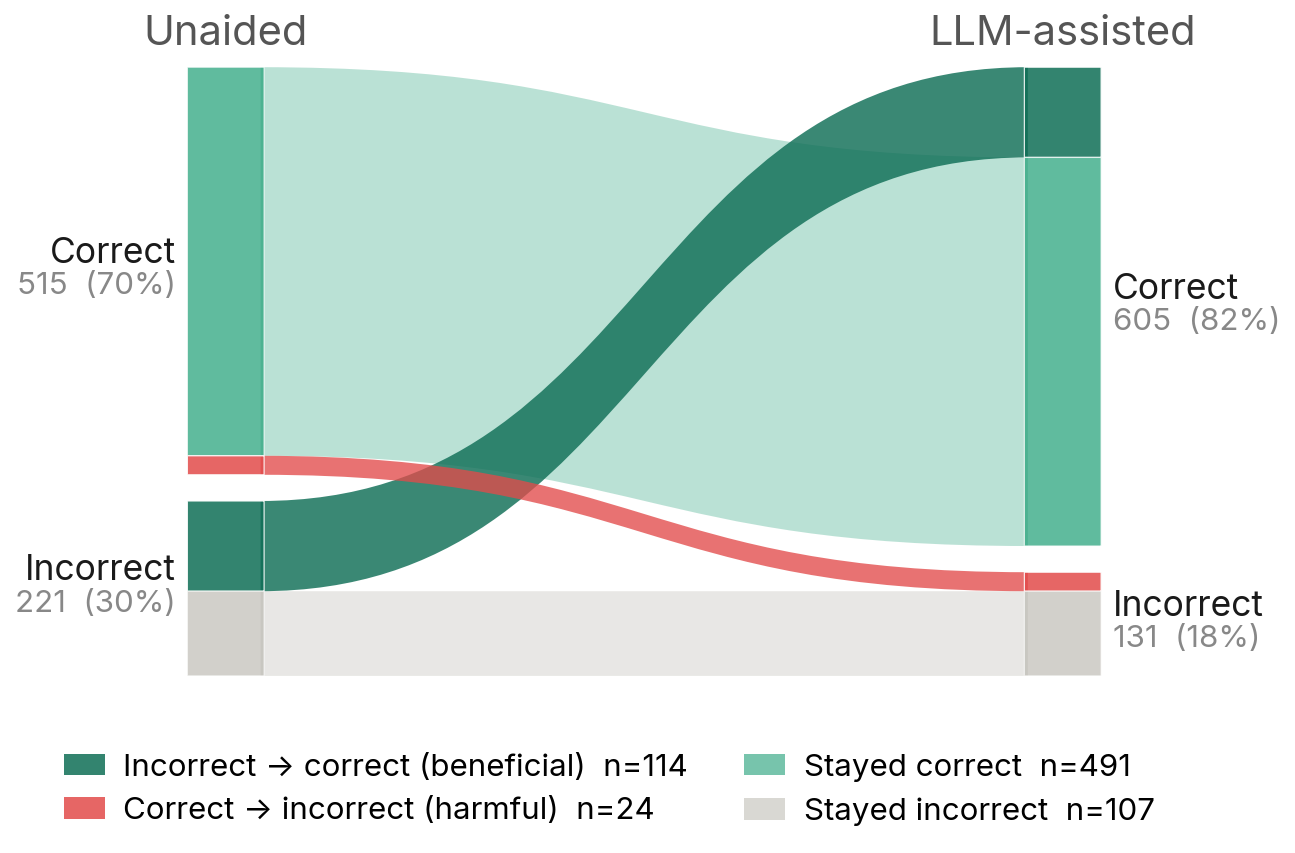

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# HORIZONTAL variant (reads left → right).  Kept alongside the vertical version
# above; saves to a separate file so the two don't overwrite each other.
# ══════════════════════════════════════════════════════════════════════════════

# ── Config ────────────────────────────────────────────────────────────────────
RESPONSES = "../results/reader_study/responses.csv"   # set to None to use counts below
CC, CW, WC, WW = 311, 34, 89, 206                    # used when RESPONSES is None

OUT = "../plots/reader_study/change_flows_horizontal.png"   # set to None to skip saving

# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path as MPath

# ── Load data ─────────────────────────────────────────────────────────────────
if RESPONSES is not None:
    df = pd.read_csv(RESPONSES)
    a  = df[df["answered"]].copy()
    N  = len(a)
    CC = int((a["initial_correct"] &  a["final_correct"]).sum())
    CW = int((a["initial_correct"] & ~a["final_correct"]).sum())
    WC = int((~a["initial_correct"] &  a["final_correct"]).sum())
    WW = int((~a["initial_correct"] & ~a["final_correct"]).sum())
else:
    N = CC + CW + WC + WW

# ── Palette ───────────────────────────────────────────────────────────────────
C_STAY_OK  = "#1D9E75"   # stayed correct   (teal)
C_BENEF    = "#0F6E56"   # wrong → correct  (dark teal)
C_HARM     = "#E24B4A"   # correct → wrong  (red)
C_STAY_BAD = "#B4B2A9"   # stayed incorrect (grey)
T_DARK     = "#1A1A1A"
T_MID      = "#555555"
T_LITE     = "#888888"

# ── Font sizes (bumped for manuscript legibility) ───────────────────────────────
FS_HEADER     = 20   # column headers
FS_LABEL_BOLD = 17   # band label line 1 (Correct / Incorrect)
FS_LABEL_LITE = 15   # band label line 2 (counts / %)
FS_FLOW       = 14   # flow labels
FS_LEGEND     = 15   # legend text

plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Inter Variable", "Inter", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size":        14,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
    "pdf.fonttype":     42,
    "ps.fonttype":      42,
    **{f"axes.spines.{s}": False for s in ("top", "right", "left", "bottom")},
})

# ── Layout ────────────────────────────────────────────────────────────────────
SCALE   = 280 / N      # total usable height in data units → px
BAR_W   = 0.06         # bar width in axes [0,1] coords
GAP     = N * 0.045    # gap between correct / incorrect bands on each side
XL, XR  = 0.14, 0.86  # x positions of left / right bars

# Left column (unaided):   correct = CC+CW, incorrect = WC+WW
# Right column (assisted): correct = CC+WC, incorrect = CW+WW
L_C = CC + CW;  L_W = WC + WW
R_C = CC + WC;  R_W = CW + WW

top = L_C + GAP + L_W   # total axis height (same both sides: N + GAP)

# Band extents (top-down: correct first, then incorrect)
Lc_hi, Lc_lo = top,         top - L_C
Lw_hi, Lw_lo = Lc_lo - GAP, Lc_lo - GAP - L_W
Rc_hi, Rc_lo = top,         top - R_C
Rw_hi, Rw_lo = Rc_lo - GAP, Rc_lo - GAP - R_W

# Sub-slices within each band
# Left correct band:   CC on top, CW below
L_CC = (Lc_hi,      Lc_hi - CC)
L_CW = (Lc_hi - CC, Lc_lo)
# Left incorrect band: WC on top, WW below
L_WC = (Lw_hi,      Lw_hi - WC)
L_WW = (Lw_hi - WC, Lw_lo)

# Right correct band:   WC on top (arrived from incorrect), CC below (stayed)
R_WC = (Rc_hi,      Rc_hi - WC)
R_CC = (Rc_hi - WC, Rc_lo)
# Right incorrect band: CW on top (arrived from correct), WW below (stayed)
R_CW = (Rw_hi,      Rw_hi - CW)
R_WW = (Rw_hi - CW, Rw_lo)

# ── Helpers ───────────────────────────────────────────────────────────────────
def flow(ax, x0, y0a, y0b, x1, y1a, y1b, color, alpha, bw):
    """Cubic-Bezier ribbon from [y0a,y0b]@(x0+bw) to [y1a,y1b]@x1."""
    xa = x0 + bw
    cx = (xa + x1) / 2
    verts = [
        (xa, y0a), (cx, y0a), (cx, y1a), (x1, y1a),
        (x1, y1b), (cx, y1b), (cx, y0b), (xa, y0b), (xa, y0a),
    ]
    codes = [
        MPath.MOVETO,
        MPath.CURVE4, MPath.CURVE4, MPath.CURVE4,
        MPath.LINETO,
        MPath.CURVE4, MPath.CURVE4, MPath.CURVE4,
        MPath.CLOSEPOLY,
    ]
    ax.add_patch(patches.PathPatch(
        MPath(verts, codes),
        facecolor=color, edgecolor="none", alpha=alpha, zorder=2,
    ))

def vbar(ax, x, top, bot, color, bw, alpha=1.0):
    ax.add_patch(patches.FancyBboxPatch(
        (x, bot), bw, top - bot,
        boxstyle="round,pad=0.003",
        facecolor=color, edgecolor="white", linewidth=0.6,
        alpha=alpha, zorder=4,
    ))

def band_label(ax, x, hi, lo, line1, line2, ha, dx=0):
    cy = (hi + lo) / 2
    ax.text(x + dx, cy + 1.5, line1, ha=ha, va="bottom",
            fontsize=FS_LABEL_BOLD, fontweight="bold", color=T_DARK)
    ax.text(x + dx, cy - 1.5, line2, ha=ha, va="top",
            fontsize=FS_LABEL_LITE, color=T_LITE)

def col_header(ax, x, y, text):
    ax.text(x, y, text, ha="center", va="bottom",
            fontsize=FS_HEADER, fontweight="bold", color=T_MID,
            transform=ax.transData)

def flow_label(ax, x0, bw, x1, y_left, y_right, t, text, color, dy=0):
    x = (x0 + bw) + t * (x1 - x0 - bw)
    y = y_left + t * (y_right - y_left) + dy
    ax.text(x, y, text, ha="center", va="center",
            fontsize=FS_FLOW, fontweight="500", color=color, zorder=6,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="none", alpha=0.85))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Flows — neutral first so they sit behind the changing ones
flow(ax, XL, *L_CC, XR, *R_CC, C_STAY_OK,  alpha=0.30, bw=BAR_W)
flow(ax, XL, *L_WW, XR, *R_WW, C_STAY_BAD, alpha=0.30, bw=BAR_W)
flow(ax, XL, *L_WC, XR, *R_WC, C_BENEF,    alpha=0.82, bw=BAR_W)
flow(ax, XL, *L_CW, XR, *R_CW, C_HARM,     alpha=0.78, bw=BAR_W)

# Bars — sub-sliced so bar colour matches the flow it belongs to
vbar(ax, XL, *L_CC, C_STAY_OK,  BAR_W, alpha=0.70)
vbar(ax, XL, *L_CW, C_HARM,     BAR_W, alpha=0.85)
vbar(ax, XL, *L_WC, C_BENEF,    BAR_W, alpha=0.85)
vbar(ax, XL, *L_WW, C_STAY_BAD, BAR_W, alpha=0.60)

vbar(ax, XR, *R_WC, C_BENEF,    BAR_W, alpha=0.85)
vbar(ax, XR, *R_CC, C_STAY_OK,  BAR_W, alpha=0.70)
vbar(ax, XR, *R_CW, C_HARM,     BAR_W, alpha=0.85)
vbar(ax, XR, *R_WW, C_STAY_BAD, BAR_W, alpha=0.60)

# Column headers
dx_h = BAR_W / 2
col_header(ax, XL + dx_h, top + GAP * 0.55, "Unaided")
col_header(ax, XR + dx_h, top + GAP * 0.55, "LLM-assisted")

# Band labels
DX = 0.013
band_label(ax, XL - DX, Lc_hi, Lc_lo, "Correct",   f"{L_C}  ({100*L_C/N:.0f}%)", "right")
band_label(ax, XL - DX, Lw_hi, Lw_lo, "Incorrect", f"{L_W}  ({100*L_W/N:.0f}%)", "right")
band_label(ax, XR + BAR_W + DX, Rc_hi, Rc_lo, "Correct",   f"{R_C}  ({100*R_C/N:.0f}%)", "left")
band_label(ax, XR + BAR_W + DX, Rw_hi, Rw_lo, "Incorrect", f"{R_W}  ({100*R_W/N:.0f}%)", "left")

# Flow labels
#flow_label(ax, XL, BAR_W, XR, np.mean(L_CC), np.mean(R_CC), 0.50, f"stayed correct = {CC}", C_STAY_OK)
#flow_label(ax, XL, BAR_W, XR, np.mean(L_WW), np.mean(R_WW), 0.50, f"stayed incorrect = {WW}", C_STAY_BAD)
#flow_label(ax, XL, BAR_W, XR, np.mean(L_WC), np.mean(R_WC), 0.22, f"incorrect → correct = {WC}", C_BENEF, dy=4)
#flow_label(ax, XL, BAR_W, XR, np.mean(L_CW), np.mean(R_CW), 0.78, f"correct → incorrect = {CW}", C_HARM, dy=-4)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    (C_BENEF,    0.85, f"Incorrect → correct (beneficial)  n={WC}"),
    (C_HARM,     0.85, f"Correct → incorrect (harmful)  n={CW}"),
    (C_STAY_OK,  0.60, f"Stayed correct  n={CC}"),
    (C_STAY_BAD, 0.50, f"Stayed incorrect  n={WW}"),
]
handles = [
    patches.Patch(facecolor=c, alpha=a, edgecolor="none", label=l)
    for c, a, l in legend_items
]
ax.legend(handles=handles,
          loc="upper center", bbox_to_anchor=(0.5, -0.06),
          ncol=2, frameon=False,
          fontsize=FS_LEGEND, handlelength=1.3, handletextpad=0.6, columnspacing=1.8)

# ── Title & axes ──────────────────────────────────────────────────────────────
net = WC - CW
#ax.set_title(
#    f"Physician answer changes after LLM exposure  (n = {N} case-responses)\n"
#    f"Beneficial {WC} vs harmful {CW}  ·  net +{net} correct  ({100*net/N:+.1f} pp)",
#    fontsize=11, fontweight="600", pad=16, color=T_DARK, linespacing=1.55,
#)
ax.set_xlim(0, 1)
ax.set_ylim(Rw_lo - GAP * 0.4, top + GAP * 1.1)
ax.axis("off")

# Reserve room at the bottom for the legend before the tight bbox is computed
fig.subplots_adjust(bottom=0.16)

if OUT:
    from pathlib import Path
    Path(OUT).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUT, dpi=300, bbox_inches="tight")
    print(f"Saved → {OUT}")
plt.show()

Saved → ../plots/reader_study/change_contingency.png


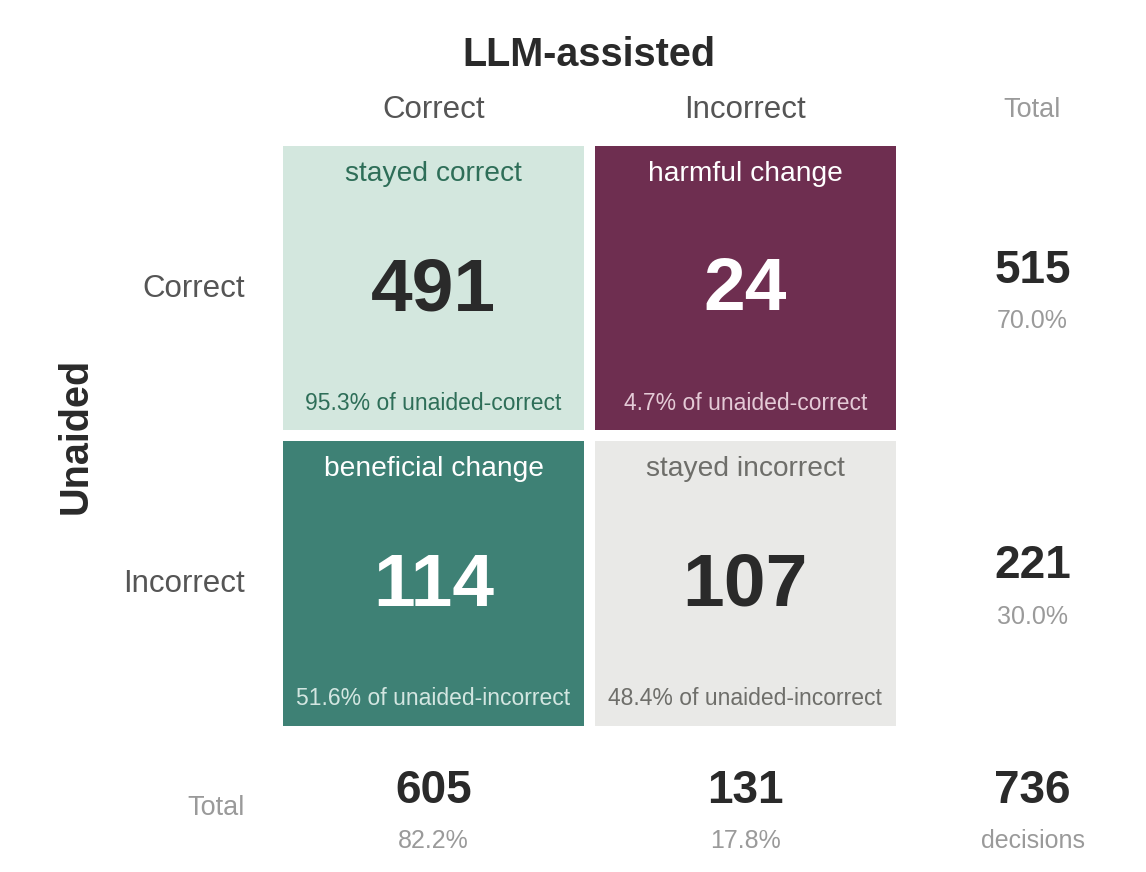

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 2x2 CONTINGENCY TABLE  (paired unaided → LLM-assisted; reads as a clinical table)
# Cell percentages are row-normalised (share of the unaided-correct / -incorrect
# answers); margins are shares of all decisions.  Same counts as the flow diagrams.
# ══════════════════════════════════════════════════════════════════════════════

# ── Config ────────────────────────────────────────────────────────────────────
RESPONSES = "../results/reader_study/responses.csv"   # set to None to use counts below
CC, CW, WC, WW = 311, 34, 89, 206                    # used when RESPONSES is None

OUT = "../plots/reader_study/change_contingency.png"  # set to None to skip saving

# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Load data ─────────────────────────────────────────────────────────────────
if RESPONSES is not None:
    df = pd.read_csv(RESPONSES)
    a  = df[df["answered"]].copy()
    N  = len(a)
    CC = int((a["initial_correct"] &  a["final_correct"]).sum())
    CW = int((a["initial_correct"] & ~a["final_correct"]).sum())
    WC = int((~a["initial_correct"] &  a["final_correct"]).sum())
    WW = int((~a["initial_correct"] & ~a["final_correct"]).sum())
else:
    N = CC + CW + WC + WW

T_C, T_W = CC + CW, WC + WW      # unaided  correct / incorrect (row totals)
B_C, B_W = CC + WC, CW + WW      # assisted correct / incorrect (col totals)

# ── Palette ────────────────────────────────────────────────────────────────────
FILL_STAY_OK  = "#D3E7DE"; INK_STAY_OK  = "#2E6E58"   # light mint / green ink
FILL_BENEF    = "#3E8175"; INK_BENEF    = "#FFFFFF"   # deep teal / white ink
FILL_HARM     = "#6E2E50"; INK_HARM     = "#FFFFFF"   # wine / white ink
FILL_STAY_BAD = "#E9E9E7"; INK_STAY_BAD = "#6E6E6A"   # light grey / grey ink
SUB_BENEF     = "#D3E6E1"                              # muted sub-text on the dark fills
SUB_HARM      = "#E4CAD6"
T_DARK, T_MID, T_LITE = "#2A2A2A", "#555555", "#9A9A9A"

# NB: Inter Variable is only registered at weight 400, so matplotlib renders every
# "bold"/"black" request as regular.  Use a static family that ships a real 700 face.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans", "Noto Sans", "Arial", "DejaVu Sans"],
    "figure.facecolor": "white", "axes.facecolor": "white",
    "figure.dpi": 150, "savefig.dpi": 300, "pdf.fonttype": 42, "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(9.6, 9.4))
ax.set_aspect("equal")         # data units square → cells render square

# grid geometry (data coords, y up)
XC0, XW = 2.40, 2.85            # left edge of data block, column width
XC1, XC2 = XC0 + XW, XC0 + 2*XW
XTOT = XC2 + 1.20              # centre of Total column
YR_TOP = 6.60                  # top of data block
RH = 2.70                      # row height (≈ column width → square)
YR_MID, YR_BOT = YR_TOP - RH, YR_TOP - 2*RH
G = 0.05                       # white gutter half-width between quadrants

def quad(x0, y0, count, label, pct_txt, fill, ink, sub_ink, count_ink=None):
    ax.add_patch(patches.Rectangle((x0 + G, y0 + G), XW - 2*G, RH - 2*G,
                 facecolor=fill, edgecolor="none", zorder=2))
    cx = x0 + XW/2
    ax.text(cx, y0 + RH - 0.30, label, fontsize=13.5, color=ink, ha="center", va="center", zorder=5)
    ax.text(cx, y0 + RH/2 - 0.02, f"{count}", fontsize=36, color=count_ink or ink, fontweight="black",
            ha="center", va="center", zorder=5)
    ax.text(cx, y0 + 0.30, pct_txt, fontsize=11, color=sub_ink, ha="center", va="center", zorder=5)

# data quadrants (percentages normalised within the unaided row)
# light-fill cells keep their tinted label but render the big count in near-black ink
quad(XC0, YR_MID, CC, "stayed correct",     f"{100*CC/T_C:.1f}% of unaided-correct",   FILL_STAY_OK,  INK_STAY_OK,  INK_STAY_OK,  count_ink=T_DARK)
quad(XC1, YR_MID, CW, "harmful change",     f"{100*CW/T_C:.1f}% of unaided-correct",   FILL_HARM,     INK_HARM,     SUB_HARM)
quad(XC0, YR_BOT, WC, "beneficial change",  f"{100*WC/T_W:.1f}% of unaided-incorrect", FILL_BENEF,    INK_BENEF,    SUB_BENEF)
quad(XC1, YR_BOT, WW, "stayed incorrect",   f"{100*WW/T_W:.1f}% of unaided-incorrect", FILL_STAY_BAD, INK_STAY_BAD, INK_STAY_BAD, count_ink=T_DARK)

# ── Titles / headers ───────────────────────────────────────────────────────────
ax.text((XC0 + XC2)/2, YR_TOP + 0.78, "LLM-assisted", fontsize=24, fontweight="black",
        color=T_DARK, ha="center", va="center")
ax.text(XC0 + XW/2, YR_TOP + 0.28, "Correct",   fontsize=19, color=T_MID, ha="center", va="center")
ax.text(XC1 + XW/2, YR_TOP + 0.28, "Incorrect", fontsize=19, color=T_MID, ha="center", va="center")
ax.text(XTOT,       YR_TOP + 0.28, "Total",     fontsize=17, color=T_LITE, ha="center", va="center")

# row super-title + sub-labels
ax.text(0.55, (YR_TOP + YR_BOT)/2, "Unaided", fontsize=24, fontweight="black",
        color=T_DARK, ha="center", va="center", rotation=90)
ax.text(XC0 - 0.30, YR_MID + RH/2, "Correct",   fontsize=19, color=T_MID, ha="right", va="center")
ax.text(XC0 - 0.30, YR_BOT + RH/2, "Incorrect", fontsize=19, color=T_MID, ha="right", va="center")

# ── Margin totals (plain text, no fill) ────────────────────────────────────────
def margin(x, yctr, big, small):
    ax.text(x, yctr + 0.16, big,   fontsize=27, color=T_DARK, fontweight="bold", ha="center", va="center")
    ax.text(x, yctr - 0.30, small, fontsize=15, color=T_LITE, ha="center", va="center")

margin(XTOT, YR_MID + RH/2, f"{T_C}", f"{100*T_C/N:.1f}%")   # unaided correct
margin(XTOT, YR_BOT + RH/2, f"{T_W}", f"{100*T_W/N:.1f}%")   # unaided incorrect

Y_BROW = YR_BOT - 0.70
ax.text(XC0 - 0.30, Y_BROW, "Total", fontsize=17, color=T_LITE, ha="right", va="center")
margin(XC0 + XW/2, Y_BROW, f"{B_C}", f"{100*B_C/N:.1f}%")    # assisted correct
margin(XC1 + XW/2, Y_BROW, f"{B_W}", f"{100*B_W/N:.1f}%")    # assisted incorrect
margin(XTOT,       Y_BROW, f"{N}",   "decisions")            # grand total

ax.set_xlim(0.0, XTOT + 0.9)
ax.set_ylim(Y_BROW - 0.45, YR_TOP + 1.15)
ax.axis("off")

if OUT:
    from pathlib import Path
    Path(OUT).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(OUT, dpi=300, bbox_inches="tight")
    print(f"Saved → {OUT}")
plt.show()